In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
from datetime import datetime
from matplotlib import cm
import seaborn as sns
import math
sns.set(style='whitegrid')

In [2]:
widths = [256, 512]
num_exps = [16, 8, 4, 2]  # Note: different from OWT
lrs = [0.0625, 0.03125, 0.015625, 0.0078125, 0.00390625, 0.001953125, 
               0.0009765625, 0.00048828125, 0.000244140625, 0.0001220703125] 
seeds = [1]
depth = 4  # Fixed depth for Shakespeare

In [3]:
results = {}
time = '20250831_033552'
for lr in lrs:
    for width in widths:
        for num_exp in num_exps:
            num_act = int(num_exp / 2)
            for seed in seeds:
                file_name = f'../run_data/mutransfer_lr_shakespeare_char/out_{time}/width{width}_depth{depth}_experts{num_exp}_active{num_act}_seed{seed}_lr{lr}/log.csv'
                if os.path.exists(file_name):
                    csv_df = pd.read_csv(file_name)
                    val_loss = csv_df.iloc[-1]['val/loss']
                    if val_loss > 0.0:
                        results[(width, num_exp, num_act, seed, lr)] = val_loss
                    else:
                        print(f"No validation loss found for {file_name}, trial ended at iteration {csv_df.shape[0]}")
                else:
                    print(f"File {file_name} does not exist, check your path")


No validation loss found for ../run_data/mutransfer_lr_shakespeare_char/out_20250831_033552/width256_depth4_experts16_active8_seed1_lr0.0625/log.csv, trial ended at iteration 326
No validation loss found for ../run_data/mutransfer_lr_shakespeare_char/out_20250831_033552/width256_depth4_experts8_active4_seed1_lr0.0625/log.csv, trial ended at iteration 269
No validation loss found for ../run_data/mutransfer_lr_shakespeare_char/out_20250831_033552/width256_depth4_experts4_active2_seed1_lr0.0625/log.csv, trial ended at iteration 226
No validation loss found for ../run_data/mutransfer_lr_shakespeare_char/out_20250831_033552/width256_depth4_experts2_active1_seed1_lr0.0625/log.csv, trial ended at iteration 274
No validation loss found for ../run_data/mutransfer_lr_shakespeare_char/out_20250831_033552/width512_depth4_experts16_active8_seed1_lr0.0625/log.csv, trial ended at iteration 280
No validation loss found for ../run_data/mutransfer_lr_shakespeare_char/out_20250831_033552/width512_depth4_

In [4]:
results

{(256, 2, 1, 1, 0.03125): np.float64(2.632366180419922),
 (512, 8, 4, 1, 0.03125): np.float64(2.695545196533203),
 (512, 4, 2, 1, 0.03125): np.float64(2.5426411628723145),
 (512, 2, 1, 1, 0.03125): np.float64(2.6342852115631104),
 (512, 16, 8, 1, 0.015625): np.float64(2.496049404144287),
 (512, 8, 4, 1, 0.015625): np.float64(2.496983051300049),
 (512, 4, 2, 1, 0.015625): np.float64(2.53062105178833),
 (512, 2, 1, 1, 0.015625): np.float64(2.5224123001098637),
 (256, 16, 8, 1, 0.0078125): np.float64(2.491863250732422),
 (256, 8, 4, 1, 0.0078125): np.float64(2.4922804832458496),
 (256, 4, 2, 1, 0.0078125): np.float64(2.5264151096343994),
 (256, 2, 1, 1, 0.0078125): np.float64(2.495074510574341),
 (512, 16, 8, 1, 0.0078125): np.float64(2.508819103240967),
 (512, 8, 4, 1, 0.0078125): np.float64(2.4522109031677246),
 (512, 4, 2, 1, 0.0078125): np.float64(2.4936928749084477),
 (512, 2, 1, 1, 0.0078125): np.float64(2.510775089263916),
 (256, 16, 8, 1, 0.00390625): np.float64(2.487398147583008)

Total experiments: 63

Results by configuration:
  n=2, width=256: 8 valid lr points
    Best: lr=1.953e-03, MSE=2.434834
  n=2, width=512: 9 valid lr points
    Best: lr=9.766e-04, MSE=2.449868
  n=4, width=256: 7 valid lr points
    Best: lr=3.906e-03, MSE=2.482110
  n=4, width=512: 9 valid lr points
    Best: lr=1.953e-03, MSE=2.425751
  n=8, width=256: 7 valid lr points
    Best: lr=9.766e-04, MSE=2.451013
  n=8, width=512: 8 valid lr points
    Best: lr=9.766e-04, MSE=2.411765
  n=16, width=256: 7 valid lr points
    Best: lr=4.883e-04, MSE=2.449004
  n=16, width=512: 8 valid lr points
    Best: lr=9.766e-04, MSE=2.419940

Plot saved as: plots/hp_transfer_plot_20250831_042704.png


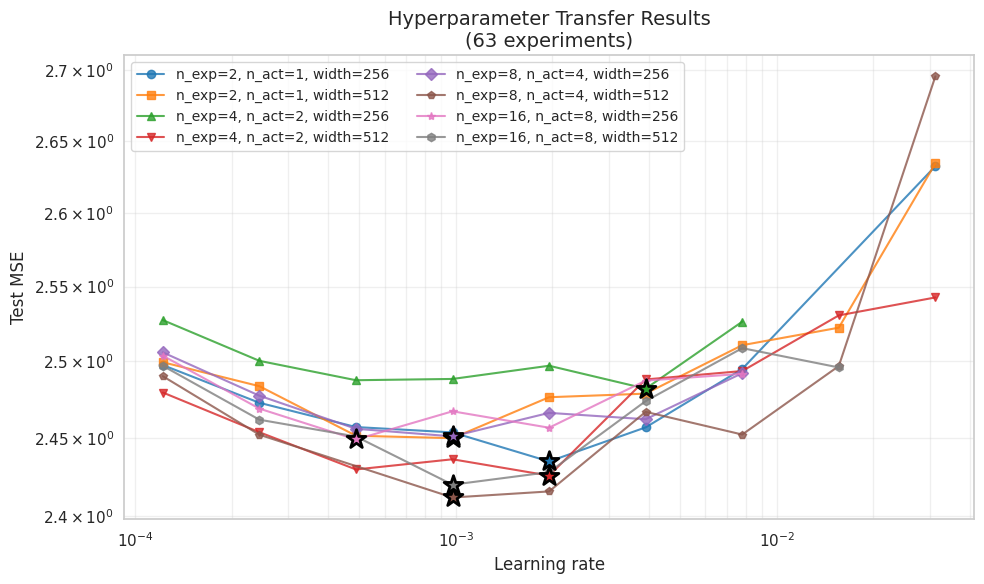

{(2, 256): [(0.0001220703125, np.float64(2.4976210594177246)),
  (0.000244140625, np.float64(2.472865581512451)),
  (0.00048828125, np.float64(2.457064628601074)),
  (0.0009765625, np.float64(2.4535892009735107)),
  (0.001953125, np.float64(2.4348340034484863)),
  (0.00390625, np.float64(2.4568538665771484)),
  (0.0078125, np.float64(2.495074510574341)),
  (0.03125, np.float64(2.632366180419922))],
 (8, 512): [(0.0001220703125, np.float64(2.490285396575928)),
  (0.000244140625, np.float64(2.452101945877075)),
  (0.0009765625, np.float64(2.4117650985717773)),
  (0.001953125, np.float64(2.415627956390381)),
  (0.00390625, np.float64(2.4669485092163086)),
  (0.0078125, np.float64(2.4522109031677246)),
  (0.015625, np.float64(2.496983051300049)),
  (0.03125, np.float64(2.695545196533203))],
 (4, 512): [(0.0001220703125, np.float64(2.479583501815796)),
  (0.000244140625, np.float64(2.453708410263061)),
  (0.00048828125, np.float64(2.429687023162842)),
  (0.0009765625, np.float64(2.436240673

In [7]:
def plot_results(result):
    plt.figure(figsize=(10, 6))
    config_results = {}
    for (width, num_exp, num_act, seed, lr), mse in result.items():
        config = (num_exp, width)
        if config not in config_results:
            config_results[config] = []
        config_results[config].append((lr, mse))
    
    # Average over seeds for each configuration and lr
    averaged_results = {}
    for config, pts in config_results.items():
        lr_to_mses = {}
        for lr, mse in pts:
            if lr not in lr_to_mses:
                lr_to_mses[lr] = []
            lr_to_mses[lr].append(mse)
        
        # Average MSEs for each lr
        averaged_pts = []
        for lr in sorted(lr_to_mses.keys()):
            avg_mse = np.mean(lr_to_mses[lr])
            averaged_pts.append((lr, avg_mse))
        averaged_results[config] = averaged_pts
    
    # Count total experiments
    total_experiments = len(result)
    print(f"Total experiments: {total_experiments}")
    
    # Print summary
    print("\nResults by configuration:")
    for (n_exp, width), pts in sorted(averaged_results.items()):
        valid_pts = [(lr, mse) for lr, mse in pts if not math.isnan(mse)]
        print(f"  n={n_exp}, width={width}: {len(valid_pts)} valid lr points")
        if valid_pts:
            best_lr, best_mse = min(valid_pts, key=lambda x: x[1])
            print(f"    Best: lr={best_lr:.3e}, MSE={best_mse:.6f}")
    
    # Plot each configuration
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h']
    
    for idx, ((n_exp, width), pts) in enumerate(sorted(averaged_results.items())):
        if pts:
            # Sort by lr for proper line plotting
            pts_sorted = sorted(pts, key=lambda t: t[0])
            lrs_plot, mses = zip(*pts_sorted)
            
            # Filter out NaN values
            valid_pts = [(lr, mse) for lr, mse in zip(lrs_plot, mses) if not math.isnan(mse)]
            
            if valid_pts:
                valid_lrs, valid_mses = zip(*valid_pts)
                color = colors[idx % len(colors)]
                marker = markers[idx % len(markers)]
                num_act = int(n_exp / 2)
                plt.plot(valid_lrs, valid_mses, marker=marker, color=color,
                        label=f'n_exp={n_exp}, n_act={num_act}, width={width}', linewidth=1.5, markersize=6,
                        alpha=0.8)
                
                # Mark the best point with a star
                best_idx = np.argmin(valid_mses)
                plt.scatter(valid_lrs[best_idx], valid_mses[best_idx], 
                           s=200, color=color, marker='*', edgecolor='black', 
                           linewidth=2, zorder=10)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'Learning rate', fontsize=12)
    plt.ylabel('Test MSE', fontsize=12)
    plt.title(f'Hyperparameter Transfer Results\n({total_experiments} experiments)', 
              fontsize=14)
    plt.legend(fontsize=10, loc='best', ncol=2)
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    
    # Save plot
    plot_dir = "plots"
    os.makedirs(plot_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plot_name = os.path.join(plot_dir, f"hp_transfer_plot_{timestamp}.png")
    plt.savefig(plot_name, dpi=150, bbox_inches='tight')
    print(f"\nPlot saved as: {plot_name}")
    
    plt.show()
    
    return averaged_results

plot_results(results)